In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 20

In [2]:
DP = DP()
all_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_all_test.fits')
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_dps_test.fits')

In [3]:
print(len(dps_df))

21178


In [4]:
dps_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [5]:
all_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

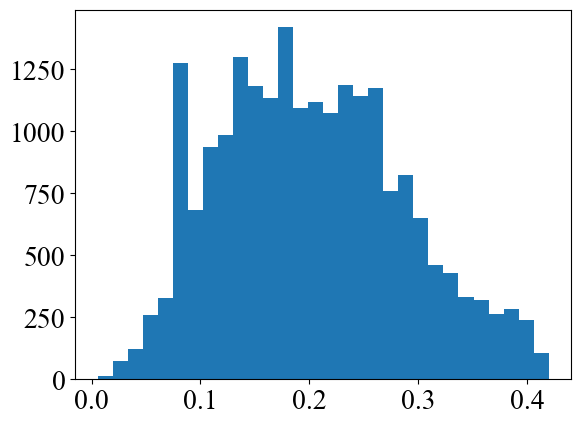

In [6]:
plt.hist(dps_df['Z'], bins=30)
plt.show()

In [7]:
print(dps_df['Z'].median())

0.19584551453590393


In [8]:
print(lam2vel(Halpha_rest[0]*(1+dps_df['Z'].median())+3*0.8, Halpha_rest[0]*(1+dps_df['Z'].median()), 0))

91.65295684054587


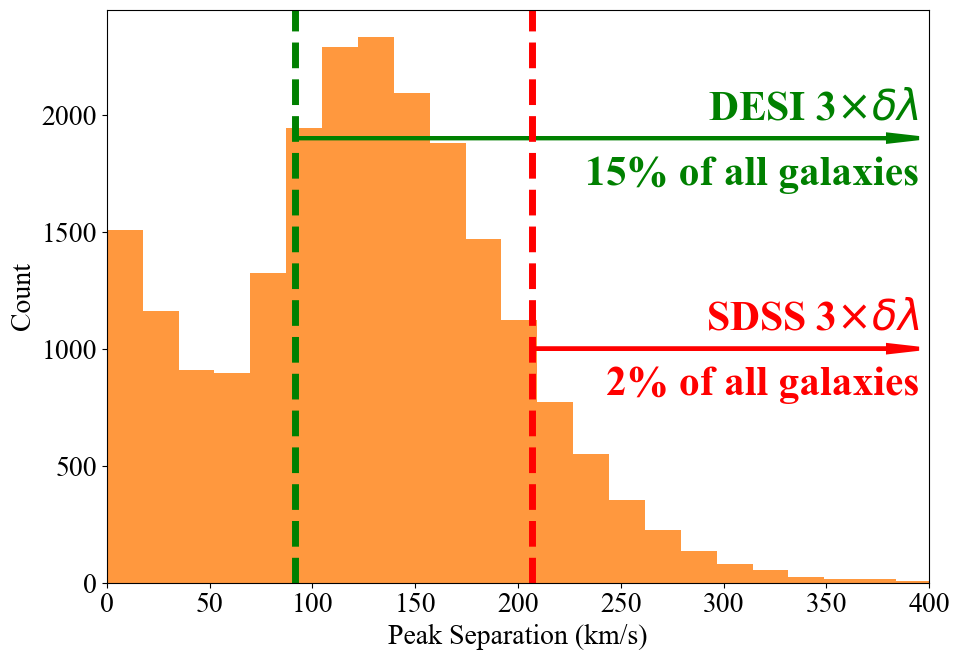

In [18]:
plt.figure(figsize=(10,7))
plt.hist(dps_df['DV_R']-dps_df['DV_L'], bins=30, color='C1', alpha=0.8)

plt.axvline(91.6, color='g', linestyle='--', linewidth=5, label=r'DESI 3$\times\delta\lambda$')
plt.arrow(91.6, 1900, 380-91.6, 0, color='g', head_width=30, head_length=15, linewidth=3)
plt.text(395, 1700, '15% of all galaxies', color='g', fontsize=30, ha='right', weight='bold')
plt.text(395, 2100, r'DESI 3$\times\delta\lambda$', color='g', fontsize=30, ha='right', va='top', weight='bold')



plt.axvline(207, color='r', linestyle='--', linewidth=5, label=r'SDSS 3$\times\delta\lambda$')
plt.arrow(207, 1000, 380-207, 0, color='r', head_width=30, head_length=15, linewidth=3)
plt.text(395, 800, '2% of all galaxies', color='r', fontsize=30, ha='right', weight='bold')
plt.text(395, 1200, r'SDSS 3$\times\delta\lambda$', color='r', fontsize=30, ha='right', va='top', weight='bold')



# plt.fill_betweenx([0, plt.ylim()[1]], 91.6, plt.xlim()[1], color='yellow', alpha=0.3, label='Intermediate Range')
plt.xlim(left=0, right=400)
plt.xlabel('Peak Separation (km/s)')
plt.ylabel('Count')
# plt.title('DP Galaxy Distribution of Peak Separations')
# plt.legend()
plt.tight_layout()
plt.savefig('./figures/asroc/peak_separation_distribution.pdf', transparent=True, bbox_inches='tight')
plt.show()

In [10]:
print(len(dps_df[dps_df['DV_R']-dps_df['DV_L'] > 91.6])/99812)
print(len(dps_df[dps_df['DV_R']-dps_df['DV_L'] > 207])/99812)

0.1497916082234601
0.023824790606339918


In [11]:
print(len(dps_df[dps_df['DV_R']-dps_df['DV_L'] > 97]))

14371


In [12]:
dps_df.sort_values('SIGMA_R', ascending=False).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
9444,39627776201852370,211.826218,-0.388770,0.177552,10.317112,0.640972,3.980152e-07,-5.649464e+01,783.734802,92.536194,...,5.566578,-1.000000,-1.000000,16,16,1,17,-0.909826,-0.308876,1
16229,39627805985604065,187.019409,0.815862,0.402560,11.157273,1.445872,1.103945e+02,-1.310192e-15,559.012329,224.689117,...,8.050861,-1.000000,-1.000000,4,16,4,20,-0.474898,-0.935062,1
17018,39627806434396707,213.866089,0.863446,0.125449,10.989308,-10.698802,8.080729e+01,-2.097159e-10,551.440186,81.764702,...,7.698963,3.378613,-1.000000,16,4,1,5,-0.237150,0.113796,1
12942,39627788474390118,223.467911,0.047747,0.068872,9.969708,-6.048626,1.890138e+02,-1.325924e+00,511.410583,104.816582,...,-1.000000,3.687352,-1.000000,1,1,1,2,-0.836874,-1.195423,1
18950,39627817914208211,178.216110,1.163323,0.135217,9.622567,0.449974,9.747923e-40,-3.693738e+00,506.798859,106.780434,...,4.345026,-1.000000,-1.000000,16,16,16,32,-0.296794,-0.833006,1
3441,39627752143327125,217.919556,-1.451486,0.277360,10.344568,1.602539,6.820584e-11,-3.066628e+00,501.751129,167.193954,...,15.724939,7.667078,6.372660,16,16,4,20,1.073853,0.921098,1
13970,39627794249941092,207.502762,0.303788,0.219927,10.641716,0.365861,1.406931e+01,-3.057646e+01,466.228607,102.903236,...,19.614475,3.866705,3.616371,4,256,4,260,-0.423100,-0.782953,2
8509,39627775719508857,183.133682,-0.603044,0.188201,11.041872,0.585675,9.301940e+01,-7.408537e-36,458.038391,245.784866,...,13.116073,7.336734,6.339234,64,4,256,260,0.347630,0.075929,1
13487,39627793998284849,192.614258,0.229326,0.046835,10.730901,-2.900370,1.380771e+01,-4.207336e+00,446.629730,165.256058,...,19.893137,9.730020,10.281447,4,4,16,20,-0.754587,-1.199186,3
12446,39627788218533694,208.098633,0.062066,0.250538,11.250815,-3.379736,1.830914e+01,-1.951036e+01,402.062775,91.288261,...,8.214255,3.156403,-1.000000,16,16,4,20,-0.446865,-1.051746,1


In [13]:
dps_df.sort_values('SIGMA_L', ascending=False).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
1472,39627745805731000,200.057358,-1.859886,0.221200,11.028525,-9.125453,1.254272e+00,-4.950966e+02,70.920113,800.000000,...,8.727003,-1.000000,-1.000000,256,256,256,512,-15.000000,-15.000000,1
2320,39627751522568102,180.848053,-1.412246,0.316521,11.136950,1.728777,1.374697e+01,-4.308124e+02,153.469727,688.979126,...,3.909745,-1.000000,-1.000000,16,1,16,17,-0.082161,-0.330777,1
5599,39627763748964880,189.638916,-1.067022,0.187426,10.452728,-5.389623,6.010919e-22,-2.701687e+02,98.955772,651.759033,...,10.581441,3.439321,3.041681,4,4,4,8,-0.926820,-1.452173,1
11006,39627782229069554,211.176483,-0.178559,0.356363,10.668675,1.205011,4.015793e-36,-6.992438e+01,142.794952,601.326904,...,3.400926,-1.000000,-1.000000,1,1,4,5,0.904063,0.849595,1
5908,39627763920931770,199.878418,-1.054401,0.219227,10.790133,0.576731,4.263085e+00,-1.260889e+02,134.100525,581.145386,...,13.190949,3.663568,-1.000000,4,1,4,5,0.970257,0.830373,1
335,39627739740767347,198.563751,-1.972422,0.246099,10.437529,1.164278,8.151340e+00,-1.113779e+02,106.561455,555.075623,...,9.377683,5.038593,3.172550,4,1,4,5,0.784091,0.928399,1
19998,39627818446882373,209.807343,1.176532,0.253174,10.410436,0.452856,2.336187e-35,-1.281771e-21,105.311630,549.754822,...,4.872424,-1.000000,-1.000000,4,1,16,17,0.046453,-0.370104,1
8119,39627770287882739,219.269287,-0.841091,0.216202,10.938835,0.416211,5.335718e+01,-2.073986e+01,195.497406,540.055359,...,6.899333,-1.000000,-1.000000,64,1,4,5,0.280936,-0.235026,1
7618,39627770032033200,204.140244,-0.660093,0.415810,10.521138,1.863829,5.802261e+01,-3.336891e+02,187.013596,538.545898,...,7.289062,-1.000000,-1.000000,4,4,4,8,0.588955,-0.249612,1
2398,39627751556126124,182.978806,-1.424618,0.296237,9.589593,1.766945,1.258120e+01,-3.629095e+01,118.999229,538.360107,...,11.063478,3.560061,3.348562,16,16,16,32,0.619709,0.419487,4
